# Week 6: Statistical Validation and Predictive Maintenance

**Notebook:** `week6_stats_and_pdm.ipynb`  
**Dataset:** `Mystery_Ops.csv`

## Project objective
This notebook completes Part A of the Week 6 technical challenge using the supplied operational dataset. The same file contains operational performance variables and sensor-style measurements, so it can support both the statistical validation and predictive maintenance (PdM) sections.

The analysis has three linked goals:

1. **Statistical validation:** test whether the maintenance condition on machine `NBI-P03` is associated with a statistically significant drop in throughput and quantify the uncertainty with 95% confidence intervals.
2. **PdM feature engineering:** create health indicators from recent temperature, voltage, and throughput history using rolling calculations.
3. **Predictive modeling:** train a logistic regression model to identify records that need maintenance attention, evaluate the model on later observations, and translate the result into business terms.

> **Method note:** The explanatory markdown in this notebook documents the analytical rationale, assumptions, and interpretation so that another analyst can follow and reproduce the work. It does not rely on hidden or undocumented steps.

## 0. Setup and reproducibility

The notebook uses common Python data-science libraries only: `pandas`, `numpy`, `matplotlib`, `scipy`, and `scikit-learn`. A fixed random seed is used where a model has a random component. The dataset loader first looks for the CSV in the same folder as the notebook, which makes the submission portable.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
RANDOM_STATE = 42

## 1. Load and inspect the operational dataset

Before testing a hypothesis or building a model, the dataset must be checked for structure, data types, missing values, and obvious labeling patterns. This step prevents the analysis from silently treating dates as text or using incomplete rows without awareness.

In [2]:
# Portable path logic: use the local file if the notebook and CSV are submitted together.
path_candidates = [Path('Mystery_Ops.csv'), Path('/mnt/data/Mystery_Ops.csv')]
DATA_PATH = next((p for p in path_candidates if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        'Mystery_Ops.csv was not found. Place the CSV in the same folder as this notebook.'
    )

raw = pd.read_csv(DATA_PATH)
print(f'Loaded: {DATA_PATH}')
print(f'Rows: {raw.shape[0]:,} | Columns: {raw.shape[1]}')
display(raw.head())

Loaded: Mystery_Ops.csv
Rows: 2,920 | Columns: 11


,record_id,operation_date,depot,shift,operator_id,machine_id,throughput_barrels,temperature_c,maintenance_flag,voltage_count,incident_type
0,MO-20260224-MOM-D,24/02/2026,Mombasa,Day,OP-M02,MBA-P01,"1,069.700",34.600,0,230,none
1,MO-20261015-KIS-D,15/10/2026,Kisumu,Day,OP-K01,KSM-P01,"1,051.600",25.500,0,227,none
2,MO-20260518-MOM-D,18/05/2026,Mombasa,Day,OP-M04,MBA-P01,999.300,37.100,0,209,none
3,MO-20260209-MOM-N,09/02/2026,Mombasa,Night,OP-M04,MBA-P03,"1,038.700",32.400,0,213,none
4,MO-20260318-MOM-N,18/03/2026,Mombasa,Night,OP-M02,MBA-P01,939.700,34.500,0,225,none


In [3]:
# Data-quality summary
quality = pd.DataFrame({
    'dtype': raw.dtypes.astype(str),
    'missing_count': raw.isna().sum(),
    'missing_pct': raw.isna().mean() * 100,
    'unique_values': raw.nunique(dropna=True),
})
display(quality)

,dtype,missing_count,missing_pct,unique_values
record_id,object,0,0.000,2920
operation_date,object,0,0.000,365
depot,object,0,0.000,4
shift,object,0,0.000,2
operator_id,object,18,0.616,15
machine_id,object,0,0.000,13
throughput_barrels,float64,5,0.171,2082
temperature_c,float64,20,0.685,266
maintenance_flag,int64,0,0.000,2
voltage_count,int64,0,0.000,44


### Data preparation decisions

- `operation_date` is stored as day/month/year, so it is parsed with `dayfirst=True`.
- Missing values are **not** filled globally. Statistical tests use complete throughput records only, while the predictive pipeline handles feature missingness explicitly.
- The data contains separate day and night records. A simple 12-hour shift offset is added to create an ordered event time for rolling features.
- Records are sorted within each machine before rolling calculations. This is essential because PdM features must follow the machine's operating sequence.

In [4]:
df = raw.copy()
df['operation_date'] = pd.to_datetime(df['operation_date'], dayfirst=True, errors='coerce')

df['shift_order'] = df['shift'].map({'Day': 0, 'Night': 1}).fillna(0)
df['event_time'] = df['operation_date'] + pd.to_timedelta(df['shift_order'] * 12, unit='h')

df = df.sort_values(['machine_id', 'event_time', 'record_id']).reset_index(drop=True)

summary = df.agg({
    'operation_date': ['min', 'max'],
    'throughput_barrels': ['mean', 'std'],
    'temperature_c': ['mean', 'std'],
    'voltage_count': ['mean', 'std'],
})
display(summary)

,operation_date,throughput_barrels,temperature_c,voltage_count
min,2026-01-01,NaN,NaN,NaN
max,2026-12-31,NaN,NaN,NaN
mean,NaT,916.891,25.050,221.123
std,NaT,168.123,5.568,6.518


In [5]:
# Operational summary by machine: this helps identify where the strongest maintenance signal exists.
machine_summary = (
    df.groupby('machine_id')
      .agg(
          records=('record_id', 'size'),
          mean_throughput=('throughput_barrels', 'mean'),
          sd_throughput=('throughput_barrels', 'std'),
          mean_temperature=('temperature_c', 'mean'),
          maintenance_rate=('maintenance_flag', 'mean'),
          incident_rate=('incident_type', lambda s: (s != 'none').mean()),
      )
      .sort_values('mean_throughput', ascending=False)
)
display(machine_summary.round(3))

,records,mean_throughput,sd_throughput,mean_temperature,maintenance_rate,incident_rate
machine_id,,,,,,
NBI-P04,47,"1,031.300",96.596,24.589,0.000,0.021
NBI-P02,51,"1,026.063",113.780,23.712,0.000,0.059
NBI-P01,66,"1,021.376",83.006,24.615,0.000,0.030
MBA-P02,244,"1,017.872",81.975,30.736,0.000,0.008
MBA-P03,242,"1,017.775",85.413,30.342,0.000,0.025
MBA-P01,244,"1,011.923",79.072,30.310,0.000,0.012
KSM-P02,229,987.106,79.886,27.146,0.000,0.004
KSM-P01,250,977.178,89.470,26.656,0.000,0.020
KSM-P03,251,974.048,96.656,26.917,0.000,0.020


## 2. Statistical Validation

### 2.1 Hypothesis

The machine-level summary shows that `NBI-P03` has a persistent maintenance flag and substantially lower throughput than the other machines. Rather than comparing two different machine designs, the statistical test compares **the same machine under two operating states**.

- **Null hypothesis (H0):** The mean throughput of `NBI-P03` is the same when the maintenance flag is 0 and when it is 1.
- **Alternative hypothesis (H1):** The mean throughput of `NBI-P03` is higher when the maintenance flag is 0 than when it is 1.
- **Significance level:** α = 0.05.

A **Welch independent-samples t-test** is appropriate because the two groups have very different sample sizes and should not be assumed to have equal variance. A one-sided test is used because the operational question is directional: whether the maintenance-flagged state has lower throughput.

In [6]:
nbi_p03 = df.loc[df['machine_id'].eq('NBI-P03')].dropna(subset=['throughput_barrels']).copy()

healthy_throughput = nbi_p03.loc[
    nbi_p03['maintenance_flag'].eq(0), 'throughput_barrels'
]
flagged_throughput = nbi_p03.loc[
    nbi_p03['maintenance_flag'].eq(1), 'throughput_barrels'
]

group_stats = pd.DataFrame({
    'state': ['Unflagged / flag = 0', 'Maintenance flagged / flag = 1'],
    'n': [len(healthy_throughput), len(flagged_throughput)],
    'mean_throughput': [healthy_throughput.mean(), flagged_throughput.mean()],
    'sd_throughput': [healthy_throughput.std(ddof=1), flagged_throughput.std(ddof=1)],
})
display(group_stats.round(3))

,state,n,mean_throughput,sd_throughput
0,Unflagged / flag = 0,21,"1,027.690",129.735
1,Maintenance flagged / flag = 1,545,617.910,67.537


In [7]:
# Welch's t-test with the directional alternative: healthy throughput > flagged throughput.
t_result = stats.ttest_ind(
    healthy_throughput,
    flagged_throughput,
    equal_var=False,
    alternative='greater'
)

print(f"Welch t-statistic: {t_result.statistic:.3f}")
print(f"Welch degrees of freedom: {t_result.df:.3f}")
print(f"One-sided p-value: {t_result.pvalue:.3e}")

Welch t-statistic: 14.400
Welch degrees of freedom: 20.420
One-sided p-value: 1.840e-12


### 2.2 95% confidence intervals

A p-value answers whether the observed difference is difficult to explain under H0, but it does not show the likely size of the effect. The following calculations therefore report:

1. a 95% confidence interval for the unflagged-state mean throughput;
2. a 95% confidence interval for the maintenance-flagged mean throughput; and
3. a Welch 95% confidence interval for the difference in means.

In [8]:
def mean_t_ci(values, confidence=0.95):
    values = pd.Series(values).dropna().astype(float)
    n = len(values)
    mean = values.mean()
    se = stats.sem(values)
    critical = stats.t.ppf((1 + confidence) / 2, df=n - 1)
    margin = critical * se
    return mean - margin, mean + margin


def welch_difference_ci(group_a, group_b, confidence=0.95):
    a = pd.Series(group_a).dropna().astype(float)
    b = pd.Series(group_b).dropna().astype(float)
    n1, n2 = len(a), len(b)
    m1, m2 = a.mean(), b.mean()
    s1, s2 = a.std(ddof=1), b.std(ddof=1)

    se = np.sqrt((s1**2 / n1) + (s2**2 / n2))
    df_welch = ((s1**2 / n1) + (s2**2 / n2))**2 / (
        ((s1**2 / n1)**2 / (n1 - 1)) + ((s2**2 / n2)**2 / (n2 - 1))
    )
    critical = stats.t.ppf((1 + confidence) / 2, df=df_welch)
    difference = m1 - m2
    return difference, difference - critical * se, difference + critical * se, df_welch

healthy_ci = mean_t_ci(healthy_throughput)
flagged_ci = mean_t_ci(flagged_throughput)
diff_mean, diff_low, diff_high, diff_df = welch_difference_ci(
    healthy_throughput, flagged_throughput
)

ci_table = pd.DataFrame({
    'metric': [
        'Unflagged mean throughput',
        'Maintenance-flagged mean throughput',
        'Difference: unflagged - flagged',
    ],
    'estimate': [healthy_throughput.mean(), flagged_throughput.mean(), diff_mean],
    '95% CI lower': [healthy_ci[0], flagged_ci[0], diff_low],
    '95% CI upper': [healthy_ci[1], flagged_ci[1], diff_high],
})
display(ci_table.round(2))

,metric,estimate,95% CI lower,95% CI upper
0,Unflagged mean throughput,"1,027.690",968.640,"1,086.750"
1,Maintenance-flagged mean throughput,617.910,612.230,623.590
2,Difference: unflagged - flagged,409.780,350.500,469.070


In [9]:
alpha = 0.05
if t_result.pvalue < alpha:
    decision = 'Reject H0'
else:
    decision = 'Fail to reject H0'

print('PLAIN-ENGLISH INTERPRETATION')
print('-' * 70)
print(f'{decision} at the 5% significance level.')
print(
    f'NBI-P03 averaged {healthy_throughput.mean():.1f} barrels when not maintenance-flagged '
    f'and {flagged_throughput.mean():.1f} barrels when maintenance-flagged.'
)
print(
    f'The estimated drop is {diff_mean:.1f} barrels, with a 95% confidence interval '
    f'from {diff_low:.1f} to {diff_high:.1f} barrels.'
)
print(
    f'The one-sided p-value is {t_result.pvalue:.3e}, so the observed reduction is '
    'statistically significant and operationally large in this dataset.'
)
print(
    'This result demonstrates association, not proof that the maintenance flag itself caused '
    'the throughput loss. The flag may represent an underlying equipment condition that also '
    'drives the lower throughput.'
)

PLAIN-ENGLISH INTERPRETATION
----------------------------------------------------------------------
Reject H0 at the 5% significance level.
NBI-P03 averaged 1027.7 barrels when not maintenance-flagged and 617.9 barrels when maintenance-flagged.
The estimated drop is 409.8 barrels, with a 95% confidence interval from 350.5 to 469.1 barrels.
The one-sided p-value is 1.840e-12, so the observed reduction is statistically significant and operationally large in this dataset.
This result demonstrates association, not proof that the maintenance flag itself caused the throughput loss. The flag may represent an underlying equipment condition that also drives the lower throughput.


## 3. Predictive Maintenance Feature Engineering

### 3.1 Target definition

The required model needs a binary outcome. The notebook defines **`needs_maintenance`** as:

- `1` when `maintenance_flag == 1`, or the incident is specifically `missed_maintenance` or `brief_equipment_fault`;
- `0` otherwise.

`operator_blunder` is deliberately excluded from the maintenance target because it is primarily a human-operational event rather than a machine-health event.

### 3.2 Health-feature logic

For each machine, the previous seven observations are summarized. The feature window is shifted by one record first, so the current target row is not used to build its own historical health features. This is a simple leakage-control step.

The engineered features are:

1. **Temperature rolling mean (7 observations):** recent thermal level.
2. **Temperature-change RMS (7 observations):** recent magnitude of shift-to-shift thermal changes; this uses RMS on temperature changes rather than raw Celsius values.
3. **Temperature range (7 observations):** short-term thermal instability.
4. **Voltage rolling standard deviation (7 observations):** electrical variability.
5. **Throughput rolling mean (7 observations):** recent process-performance level.
6. **Throughput range (7 observations):** short-term production instability.

The assignment requires at least three health features; six are retained so the model can compare sensor context with process-performance behavior.

In [10]:
# Binary maintenance target
maintenance_incidents = {'missed_maintenance', 'brief_equipment_fault'}
df['needs_maintenance'] = (
    df['maintenance_flag'].eq(1) |
    df['incident_type'].isin(maintenance_incidents)
).astype(int)

print('Target distribution:')
display(
    df['needs_maintenance']
      .value_counts()
      .rename_axis('needs_maintenance')
      .to_frame('count')
      .assign(percent=lambda x: 100 * x['count'] / x['count'].sum())
      .round(2)
)

Target distribution:


,count,percent
needs_maintenance,,
0,2357,80.720
1,563,19.280


In [11]:
WINDOW = 7
MIN_PERIODS = 3

# Lag each raw signal by one observation within machine so rolling features use prior history only.
for col in ['temperature_c', 'voltage_count', 'throughput_barrels']:
    df[f'{col}_lag1'] = df.groupby('machine_id')[col].shift(1)

# Temperature features
_temp_group = df.groupby('machine_id')['temperature_c_lag1']
df['temp_rolling_mean_7'] = (
    _temp_group.rolling(WINDOW, min_periods=MIN_PERIODS).mean()
    .reset_index(level=0, drop=True)
)
df['temp_change'] = df.groupby('machine_id')['temperature_c'].diff()
df['temp_change_lag1'] = df.groupby('machine_id')['temp_change'].shift(1)
df['temp_change_rms_7'] = np.sqrt(
    (df['temp_change_lag1'] ** 2)
    .groupby(df['machine_id'])
    .rolling(WINDOW, min_periods=MIN_PERIODS)
    .mean()
    .reset_index(level=0, drop=True)
)
_temp_roll = _temp_group.rolling(WINDOW, min_periods=MIN_PERIODS)
df['temp_range_7'] = (
    _temp_roll.max().reset_index(level=0, drop=True)
    - _temp_roll.min().reset_index(level=0, drop=True)
)

# Voltage variability
_voltage_group = df.groupby('machine_id')['voltage_count_lag1']
df['voltage_std_7'] = (
    _voltage_group.rolling(WINDOW, min_periods=MIN_PERIODS).std()
    .reset_index(level=0, drop=True)
)

# Process-performance features
_thr_group = df.groupby('machine_id')['throughput_barrels_lag1']
df['throughput_rolling_mean_7'] = (
    _thr_group.rolling(WINDOW, min_periods=MIN_PERIODS).mean()
    .reset_index(level=0, drop=True)
)
_thr_roll = _thr_group.rolling(WINDOW, min_periods=MIN_PERIODS)
df['throughput_range_7'] = (
    _thr_roll.max().reset_index(level=0, drop=True)
    - _thr_roll.min().reset_index(level=0, drop=True)
)

FEATURES = [
    'temp_rolling_mean_7',
    'temp_change_rms_7',
    'temp_range_7',
    'voltage_std_7',
    'throughput_rolling_mean_7',
    'throughput_range_7',
]

display(df[['machine_id', 'event_time', 'needs_maintenance'] + FEATURES].head(12))

,machine_id,event_time,needs_maintenance,temp_rolling_mean_7,temp_change_rms_7,temp_range_7,voltage_std_7,throughput_rolling_mean_7,throughput_range_7
0,ELD-P01,2026-01-02 00:00:00,0,NaN,NaN,NaN,NaN,NaN,NaN
1,ELD-P01,2026-01-02 12:00:00,0,NaN,NaN,NaN,NaN,NaN,NaN
2,ELD-P01,2026-01-03 12:00:00,0,NaN,NaN,NaN,NaN,NaN,NaN
3,ELD-P01,2026-01-06 00:00:00,0,21.133,NaN,2.000,1.528,861.467,259.800
4,ELD-P01,2026-01-08 00:00:00,0,20.225,1.974,4.900,3.096,885.900,259.800
5,ELD-P01,2026-01-08 12:00:00,0,20.320,2.341,4.900,2.864,907.480,263.800
6,ELD-P01,2026-01-09 00:00:00,0,20.117,2.213,4.900,5.456,917.483,263.800
7,ELD-P01,2026-01-09 12:00:00,0,20.057,2.035,4.900,8.080,926.786,263.800
8,ELD-P01,2026-01-10 12:00:00,0,20.314,2.538,6.700,7.547,932.143,297.300
9,ELD-P01,2026-01-11 12:00:00,0,20.243,2.895,6.700,6.543,957.600,312.800


### 3.3 Visualizing degradation trends

`NBI-P03` is used as the case-study machine because the statistical section identified a clear change in its operating condition. The vertical reference line marks the first maintenance-related target event. The charts are intentionally shown separately so each feature is easy to read.

A key analytical point is that **not every sensor-derived feature must show a strong failure signature**. If throughput changes sharply while temperature or voltage changes only weakly, that is still useful: it tells the engineer which measurements currently carry the strongest signal and which may need better sensors or thresholds.

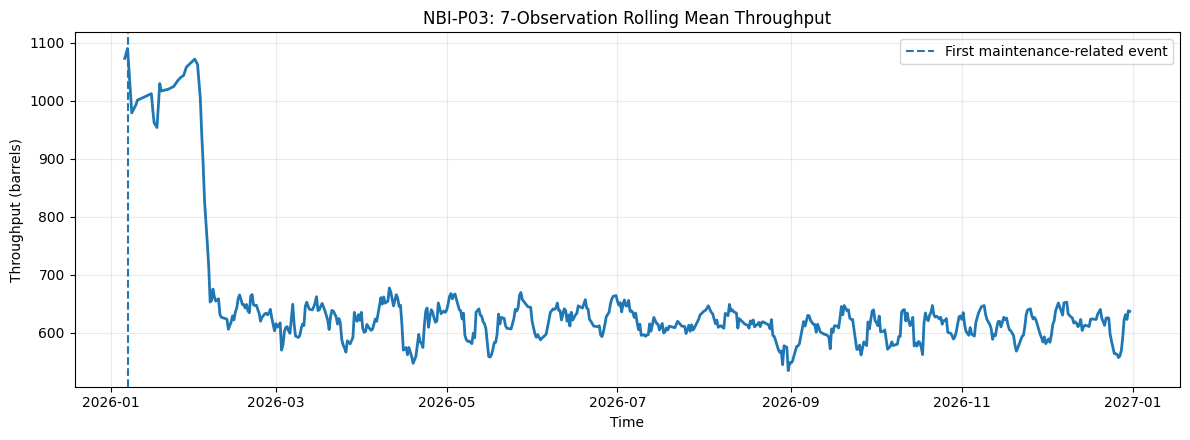

In [12]:
case_machine = 'NBI-P03'
case = df.loc[df['machine_id'].eq(case_machine)].sort_values('event_time').copy()
first_attention_time = case.loc[case['needs_maintenance'].eq(1), 'event_time'].min()

plt.figure(figsize=(12, 4.5))
plt.plot(case['event_time'], case['throughput_rolling_mean_7'], linewidth=2)
plt.axvline(first_attention_time, linestyle='--', linewidth=1.5, label='First maintenance-related event')
plt.title('NBI-P03: 7-Observation Rolling Mean Throughput')
plt.xlabel('Time')
plt.ylabel('Throughput (barrels)')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

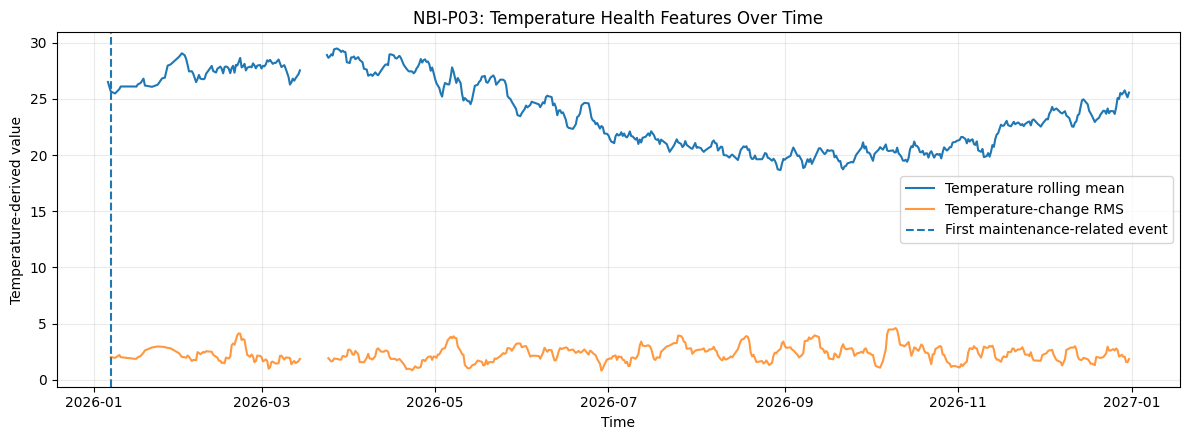

In [13]:
plt.figure(figsize=(12, 4.5))
plt.plot(case['event_time'], case['temp_rolling_mean_7'], label='Temperature rolling mean')
plt.plot(case['event_time'], case['temp_change_rms_7'], label='Temperature-change RMS', alpha=0.8)
plt.axvline(first_attention_time, linestyle='--', linewidth=1.5, label='First maintenance-related event')
plt.title('NBI-P03: Temperature Health Features Over Time')
plt.xlabel('Time')
plt.ylabel('Temperature-derived value')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

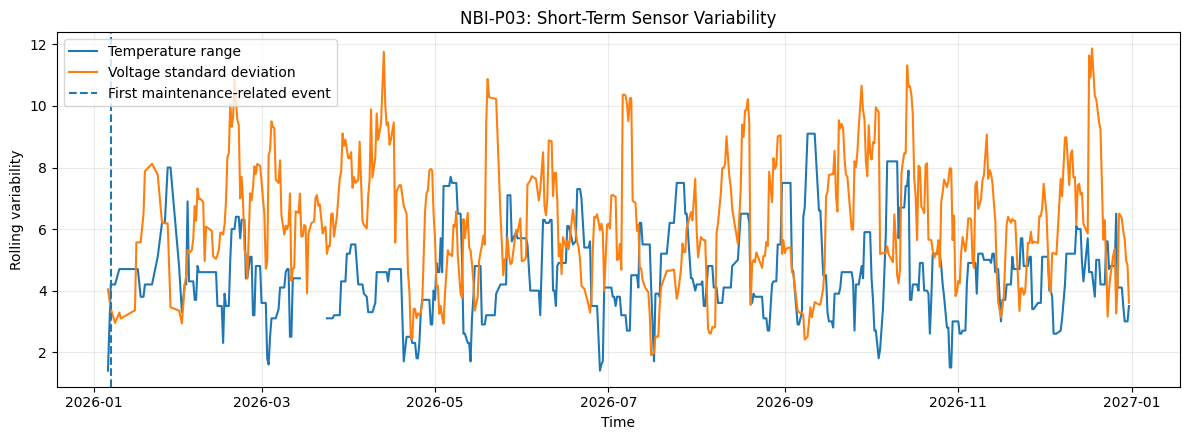

In [14]:
plt.figure(figsize=(12, 4.5))
plt.plot(case['event_time'], case['temp_range_7'], label='Temperature range')
plt.plot(case['event_time'], case['voltage_std_7'], label='Voltage standard deviation')
plt.axvline(first_attention_time, linestyle='--', linewidth=1.5, label='First maintenance-related event')
plt.title('NBI-P03: Short-Term Sensor Variability')
plt.xlabel('Time')
plt.ylabel('Rolling variability')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Feature-engineering interpretation

The rolling throughput feature should be read as a **process-health indicator**, while temperature and voltage provide sensor context. For `NBI-P03`, the main degradation signature is the persistent throughput reduction around the maintenance transition. Temperature and voltage contain weaker patterns. This matters because a production PdM system should not assume that every available sensor is equally informative.

## 4. Predictive Modeling with Logistic Regression

### Why logistic regression?

The target has two classes: `0 = no maintenance attention` and `1 = needs maintenance attention`. Logistic regression is therefore a direct match to the assignment and has an additional advantage for this exercise: its coefficients remain interpretable after standardization.

### Why a chronological split?

PdM is a time-dependent problem. A random split can let later operating patterns leak into training. This notebook trains on the earliest 75% of feature-ready observations and tests on the latest 25%. That is a more realistic demonstration of how a model would be used on future operations.

The pipeline uses median imputation, standardization, and `class_weight='balanced'` to reduce bias toward the majority healthy class.

In [15]:
model_df = (
    df.dropna(subset=FEATURES + ['event_time', 'needs_maintenance'])
      .sort_values('event_time')
      .copy()
)

cutoff_time = model_df['event_time'].quantile(0.75)
train = model_df.loc[model_df['event_time'] <= cutoff_time].copy()
test = model_df.loc[model_df['event_time'] > cutoff_time].copy()

X_train, y_train = train[FEATURES], train['needs_maintenance']
X_test, y_test = test[FEATURES], test['needs_maintenance']

split_summary = pd.DataFrame({
    'sample': ['Train', 'Test'],
    'rows': [len(train), len(test)],
    'positive_cases': [int(y_train.sum()), int(y_test.sum())],
    'positive_rate_pct': [100 * y_train.mean(), 100 * y_test.mean()],
    'start_time': [train['event_time'].min(), test['event_time'].min()],
    'end_time': [train['event_time'].max(), test['event_time'].max()],
})
print(f'Chronological cutoff: {cutoff_time}')
display(split_summary.round(2))

Chronological cutoff: 2026-10-03 12:00:00


,sample,rows,positive_cases,positive_rate_pct,start_time,end_time
0,Train,2140,392,18.320,2026-01-04 12:00:00,2026-10-03 12:00:00
1,Test,712,154,21.630,2026-10-04 00:00:00,2026-12-31 12:00:00


In [16]:
model = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('logistic_regression', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=RANDOM_STATE,
    )),
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

### 4.1 Model evaluation

For maintenance screening, accuracy alone is not enough. The notebook also reports:

- **Sensitivity / recall:** percentage of true maintenance cases detected.
- **Specificity:** percentage of healthy cases correctly left unflagged.
- **False positive rate:** percentage of healthy cases incorrectly flagged.
- **Precision:** percentage of model alerts that are true maintenance cases.
- **F1 score:** balance between precision and recall.

False negatives matter because a missed maintenance case can allow degradation to continue. False positives matter because unnecessary inspections consume labor and may cause avoidable downtime.

In [17]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
accuracy = accuracy_score(y_test, y_pred)
sensitivity = recall_score(y_test, y_pred)
specificity = tn / (tn + fp)
false_positive_rate = fp / (fp + tn)
precision = precision_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred)

metrics = pd.DataFrame({
    'metric': [
        'Accuracy',
        'Sensitivity / Recall',
        'Specificity',
        'False Positive Rate',
        'Precision',
        'F1 Score',
    ],
    'value': [accuracy, sensitivity, specificity, false_positive_rate, precision, f1],
})
display(metrics.assign(value=metrics['value'].map(lambda x: f'{x:.2%}')))

print(f'True negatives:  {tn}')
print(f'False positives: {fp}')
print(f'False negatives: {fn}')
print(f'True positives:  {tp}')

,metric,value
0,Accuracy,99.44%
1,Sensitivity / Recall,98.05%
2,Specificity,99.82%
3,False Positive Rate,0.18%
4,Precision,99.34%
5,F1 Score,98.69%


True negatives:  557
False positives: 1
False negatives: 3
True positives:  151


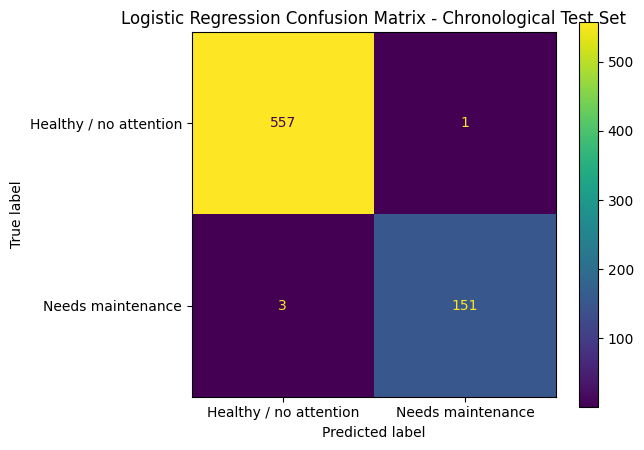

In [18]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['Healthy / no attention', 'Needs maintenance'],
    values_format='d',
)
plt.title('Logistic Regression Confusion Matrix - Chronological Test Set')
plt.tight_layout()
plt.show()

### 4.2 Which features drive the model?

Because the inputs were standardized, the logistic-regression coefficients can be compared directionally. A positive coefficient pushes the prediction toward maintenance attention, while a negative coefficient pushes it toward the healthy class. Coefficients describe model association, not causation.

In [19]:
coefficients = pd.Series(
    model.named_steps['logistic_regression'].coef_[0],
    index=FEATURES,
    name='standardized_coefficient',
).sort_values(key=np.abs, ascending=False)

display(coefficients.to_frame().round(3))

,standardized_coefficient
throughput_rolling_mean_7,-3.573
temp_change_rms_7,-0.748
temp_range_7,0.707
temp_rolling_mean_7,0.461
voltage_std_7,-0.186
throughput_range_7,-0.132


## 5. Business implication of model performance

A useful PdM model should convert data into an operational decision, not just a score. The final cell below produces a plain-English interpretation using the actual test-set results.

The model is best treated as a **proof of concept**. The dataset's maintenance label is heavily concentrated in one sustained `NBI-P03` event, which makes the pattern easier to learn than a diverse real-world failure population. A production deployment would require more machines, more independent failure episodes, maintenance work-order confirmation, and cost-based threshold tuning.

In [20]:
print('BUSINESS INTERPRETATION')
print('-' * 70)
print(
    f'On the later holdout period, the model achieved {accuracy:.1%} accuracy and '
    f'{sensitivity:.1%} sensitivity.'
)
print(
    f'It detected {tp} of {tp + fn} maintenance cases, missed {fn}, and generated '
    f'{fp} false positive alert(s) among {tn + fp} healthy cases.'
)
print(
    f'The false positive rate was {false_positive_rate:.1%}. In this sample, that means '
    'the alert logic would create very little unnecessary inspection work while still '
    'capturing nearly all maintenance-labeled conditions.'
)
print(
    'The strongest model signal is recent throughput performance, while the temperature '
    'and voltage features contribute less. Operationally, this suggests that throughput '
    'degradation should be monitored together with sensor features rather than relying on '
    'temperature or voltage alone.'
)
print(
    'Before production use, validate the model on additional equipment and independent '
    'failure events, connect predictions to confirmed maintenance work orders, and choose '
    'the alert threshold using the relative cost of missed failures versus unnecessary checks.'
)

BUSINESS INTERPRETATION
----------------------------------------------------------------------
On the later holdout period, the model achieved 99.4% accuracy and 98.1% sensitivity.
It detected 151 of 154 maintenance cases, missed 3, and generated 1 false positive alert(s) among 558 healthy cases.
The false positive rate was 0.2%. In this sample, that means the alert logic would create very little unnecessary inspection work while still capturing nearly all maintenance-labeled conditions.
The strongest model signal is recent throughput performance, while the temperature and voltage features contribute less. Operationally, this suggests that throughput degradation should be monitored together with sensor features rather than relying on temperature or voltage alone.
Before production use, validate the model on additional equipment and independent failure events, connect predictions to confirmed maintenance work orders, and choose the alert threshold using the relative cost of missed failu

## 6. Final conclusions

1. **Statistical validation:** `NBI-P03` shows a large and statistically significant throughput reduction when maintenance-flagged. The 95% confidence interval for the unflagged-versus-flagged mean difference quantifies the operational size of that reduction.
2. **PdM feature engineering:** lagged rolling features were created from temperature, voltage, and throughput so the health indicators summarize recent machine history without using future observations.
3. **Predictive model:** logistic regression was evaluated on a later chronological holdout using accuracy, confusion matrix, sensitivity, specificity, false positives, precision, and F1 score.
4. **Business implication:** the model demonstrates that recent operational history can identify the maintenance condition with strong test performance in this dataset, but the concentration of failures in one machine means broader validation is required before deployment.

### Connection to Part B
The engineering brief should emphasize sensor logic, the seven-observation lagged window, sensitivity, false positives, and the need to validate more failure modes. The executive brief should translate the result into avoided downtime, fewer unnecessary inspections, and lower operational risk. Any ROI figure should be based on clearly stated cost assumptions because this dataset does not contain maintenance cost, downtime cost, or repair-cost fields.

## 7. Short reflection on context switching

Switching from the technical analysis to an executive explanation is moderately challenging because the evidence stays the same while the decision language changes. An engineer needs to know how the rolling features, target logic, sensitivity, and false positives were produced. A CFO needs the same result translated into downtime exposure, unnecessary inspection cost, and financial risk without model terminology. The most important skill is therefore not simplifying the evidence away, but selecting the part of the evidence that is relevant to each audience.